Initial number of countries: 213
------------------------------


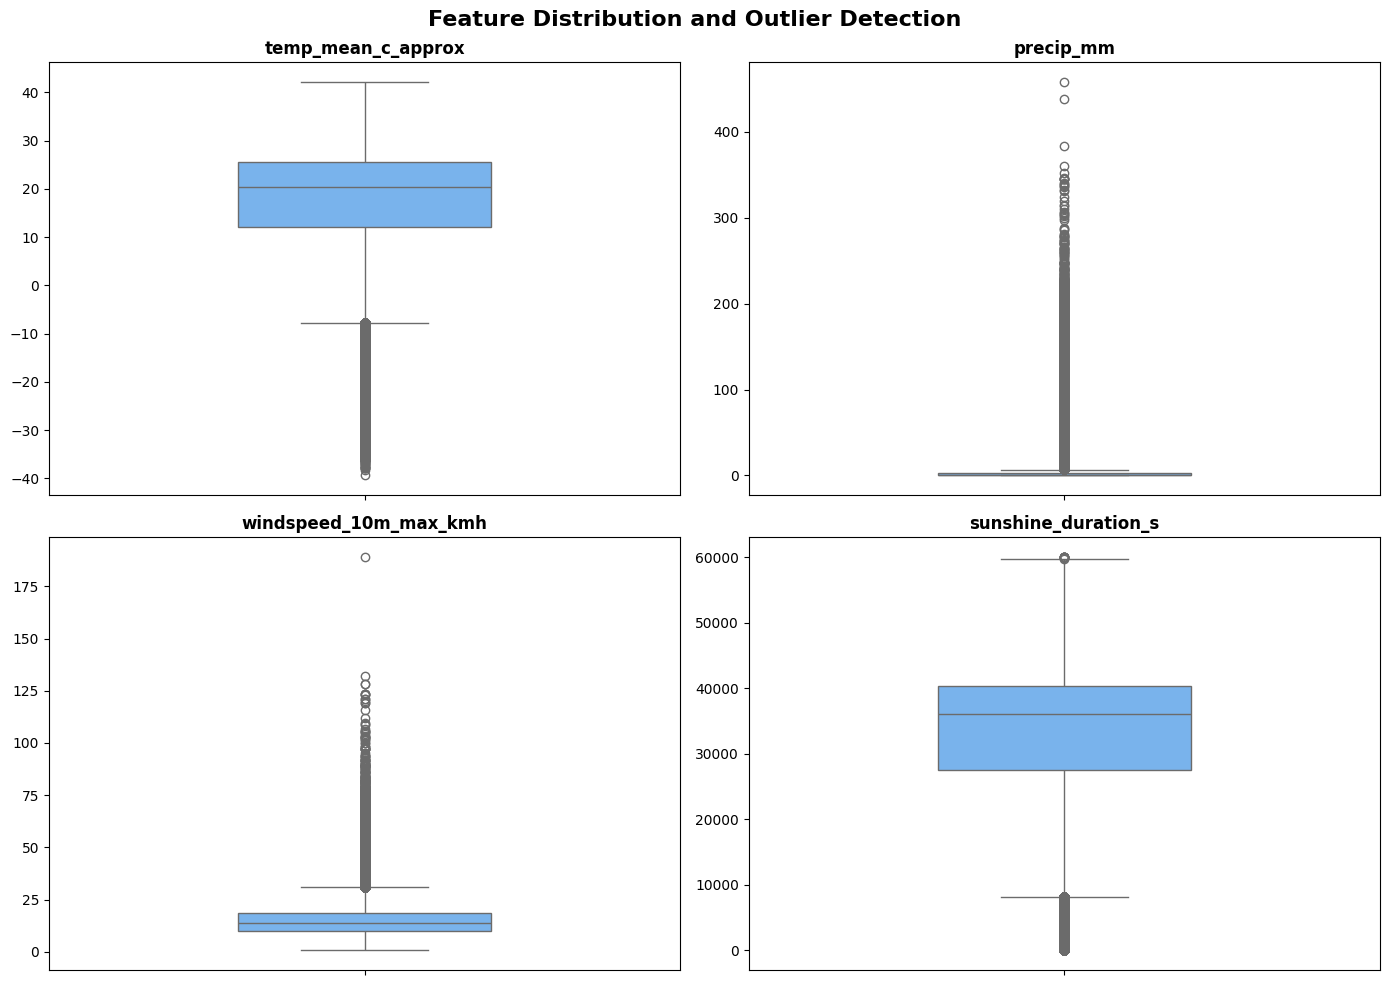

------------------------------
Number of distinct countries remaining: 213
------------------------------
temp_mean_c_approx
------------------------------
Mean: 17.494855965319182
Max value: 28.76703805091705
------------------------------
precip_mm
------------------------------
Mean: 2.683120009855869
Max value: 20.27037037037037
------------------------------
windspeed_10m_max_kmh
------------------------------
Mean: 17.766585579631233
Max value: 48.73333333333333
------------------------------
sunshine_duration_s
------------------------------
Mean: 31998.844798500744
Max value: 46974.99416666667
------------------------------


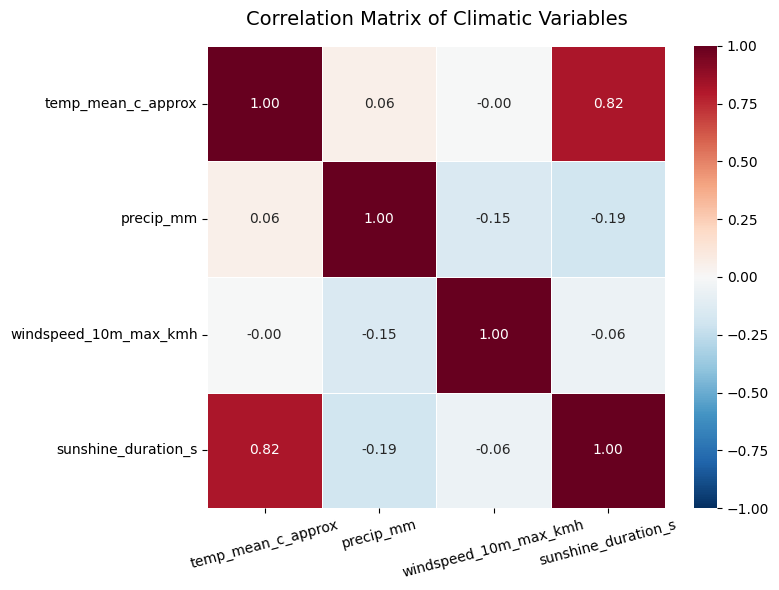

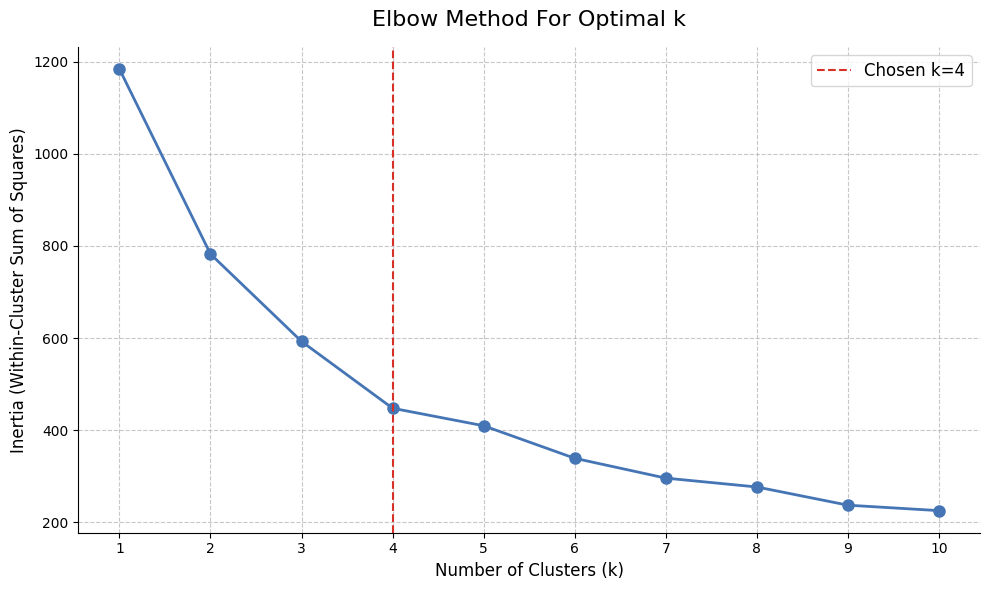

Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


Number of countries with a complete history across all decades: 41


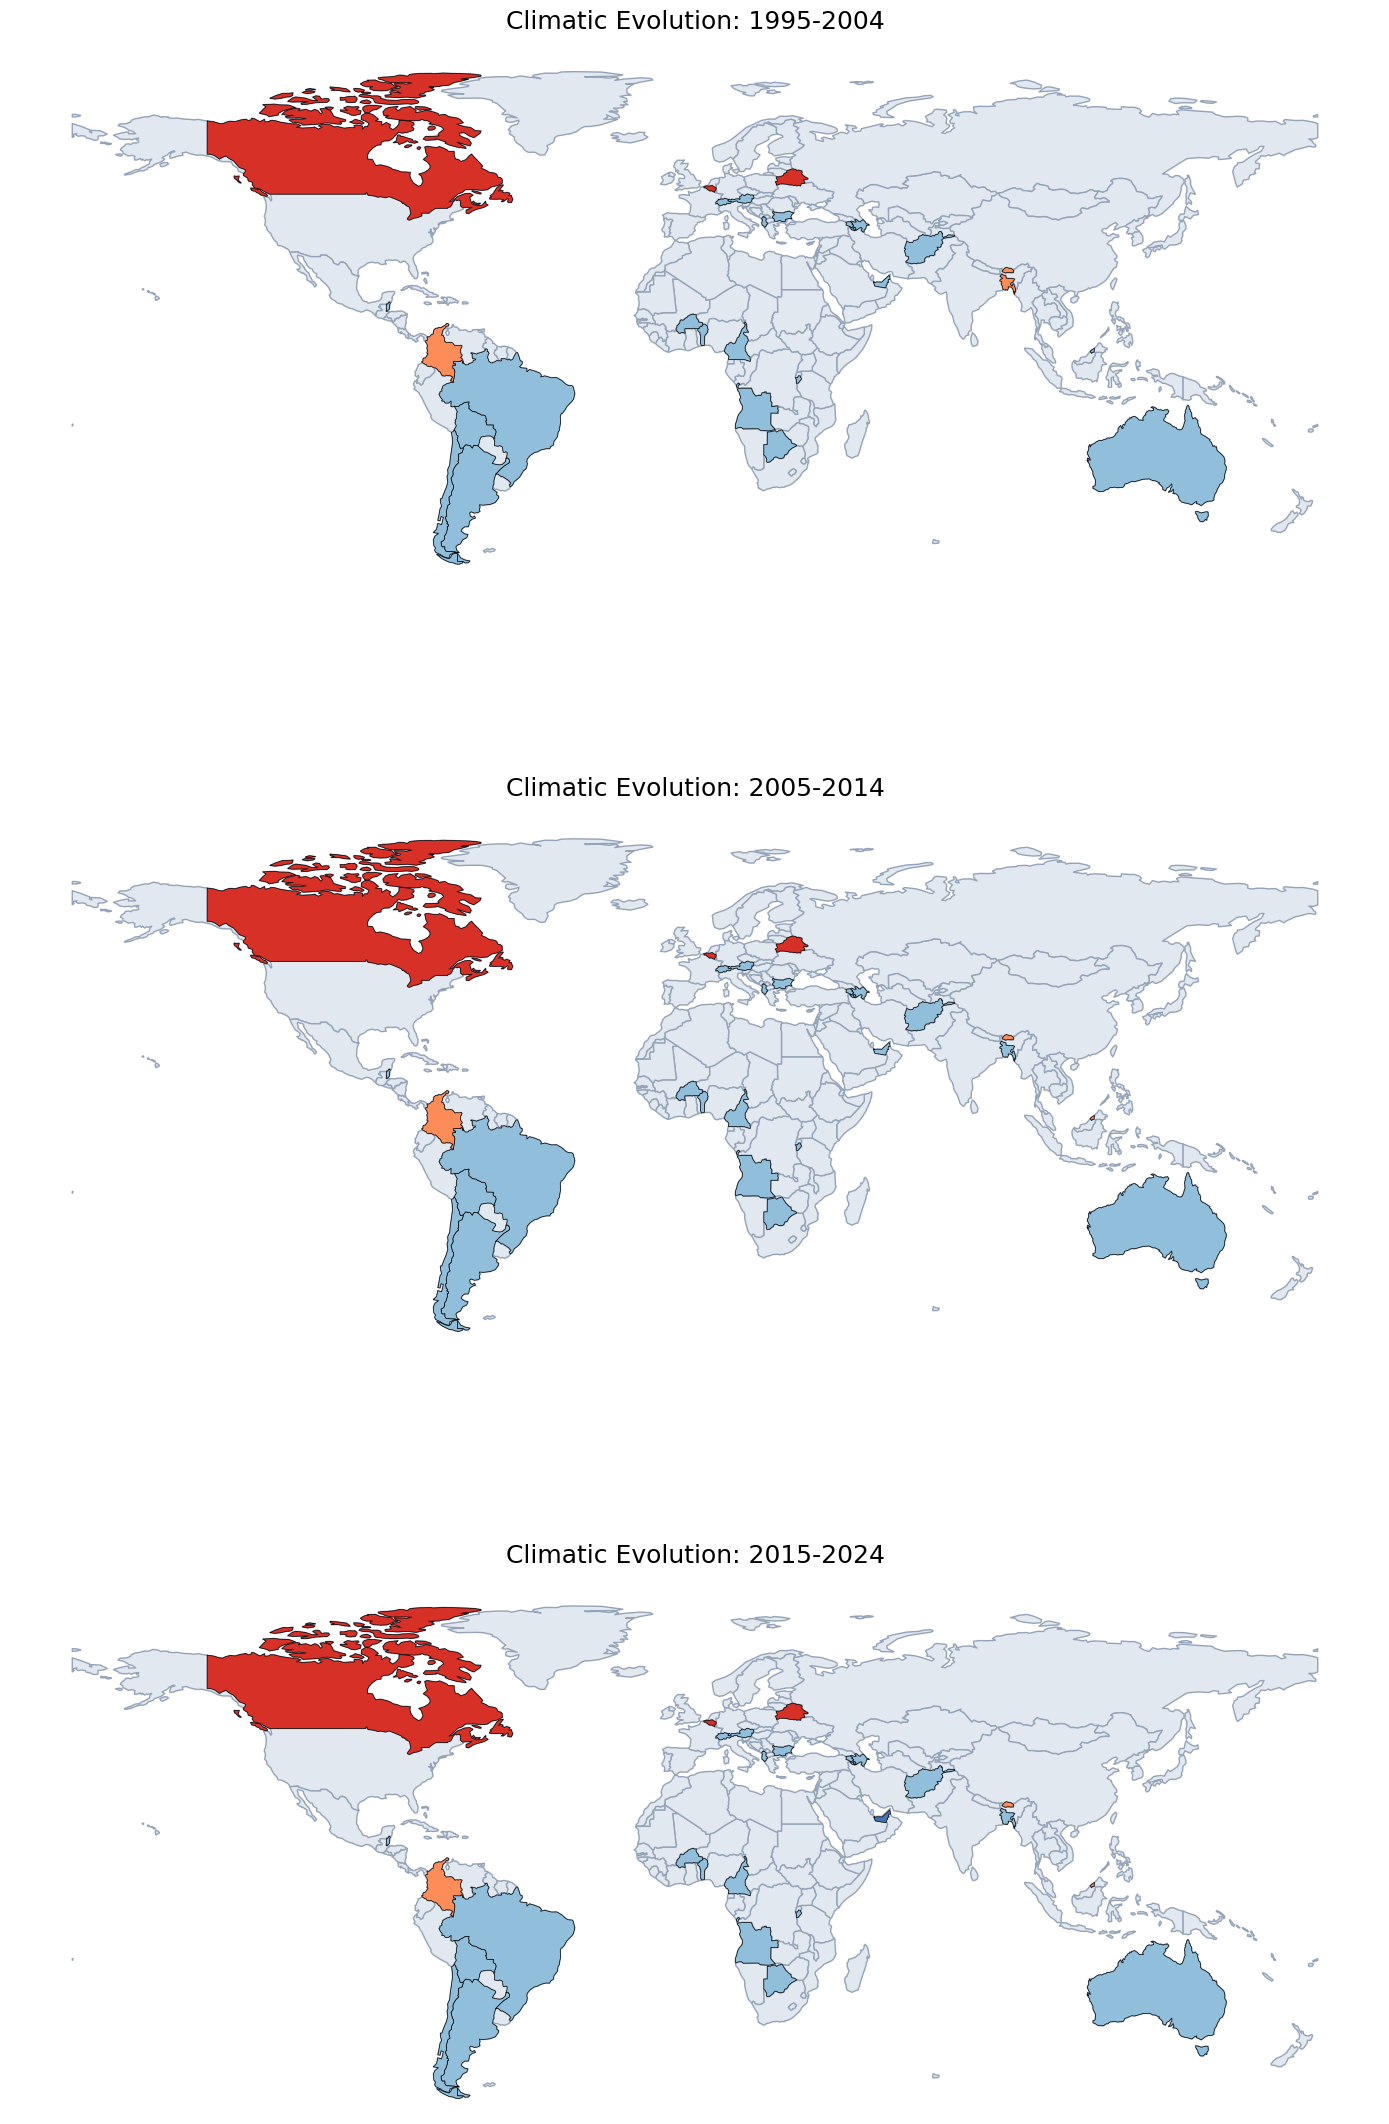

------------------------------------------------------------
Number of countries that shifted climate between Decade 1 and Decade 2: 2
------------------------------------------------------------


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)



Number of countries that shifted climate between Decade 2 and Decade 3: 1


Loading ITables v2.8.1 from the init_notebook_mode cell... (need help?)


In [12]:
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=False)
import kagglehub
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets
from shapely.geometry import Point
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# Visual variables
cluster_colors = {
    '0': '#d73027', # Hot
    '1': '#4575b4', # Cold
    '2': '#91bfdb', # Temperated
    '3': '#fc8d59'  # Equatorial
}
cluster_names = {
    '0': 'Hot',
    '1': 'Cold',
    '2': 'Temperated',
    '3': 'Ecuatorial'
}

# Loading DATABASE
path = kagglehub.dataset_download("wafaaelhusseini/major-cities-weather-data")
input_db_path = os.path.join(path, "history.parquet")
df = pd.read_parquet(input_db_path)

# Division by decade
df['years'] = pd.to_datetime(df['date']).dt.year
df['time_period'] = pd.cut(df['years'],
                           bins=[1994, 2004, 2014, 2024],
                           labels=['1995-2004', '2005-2014', '2015-2024'])

# Usefull columns for the study
climate_features = ['temp_mean_c_approx', 'precip_mm', 'windspeed_10m_max_kmh', 'sunshine_duration_s']
print(f"Initial number of countries: {df['country'].nunique()}")
print("-" * 30)

# Outliers, Means, Quartiles for any of the features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plots construction for any of the relevant features
for i, feature in enumerate(climate_features):
    sns.boxplot(y=df[feature], ax=axes[i], color='#66b3ff', width=0.4)
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle('Feature Distribution and Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Aggregation and grouping by county and decade
df_temporal = df.groupby(['country', 'time_period'], observed=True).agg({
    'temp_mean_c_approx': 'mean',
    'precip_mm': 'mean',
    'windspeed_10m_max_kmh': 'mean',
    'sunshine_duration_s': 'mean',
    'lat': 'mean',
    'lon': 'mean'
}).reset_index()

# Checking and eliminate the row with null relevant features
df_temporal = df_temporal.dropna(subset=climate_features)

# Validating the cleaned database size and extracting descriptive statistics
print("-" * 30)
print(f"Number of distinct countries remaining: {df_temporal['country'].nunique()}")
print("-" * 30)

for feature in climate_features:
    print(f"{feature}")
    print("-" * 30)
    print(f"Mean: {df_temporal[feature].mean()}")
    print(f"Max value: {df_temporal[feature].max()}")
    print("-" * 30)
plt.figure(figsize=(8, 6))

# Study of the correlation between the selected features
correlation_matrix = df_temporal[climate_features].corr()

sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='RdBu_r', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5, 
    fmt=".2f"
)

plt.title('Correlation Matrix of Climatic Variables', fontsize=14, pad=15)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Standardization of the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_temporal[climate_features])

# Elbow Method to determine the optimal number of clusters
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_test.fit(scaled_data)
    inertias.append(kmeans_test.inertia_)

# Plotting the Elbow Graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, marker='o', linestyle='-', color='#4575b4', markersize=8, linewidth=2)

plt.title('Elbow Method For Optimal k', fontsize=16, pad=15)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)

# Highlighting the chosen optimal k=4
plt.axvline(x=4, color='#d73027', linestyle='--', label='Chosen k=4')
plt.legend(fontsize=12)

# Eliminating unnecessary borders for a cleaner look
sns.despine()

plt.tight_layout()
plt.show()

# K-MEANS MODEL
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# Assigning labels (cluster 0, 1, 2, or 3) to each country-decade profile
df_temporal['climate_cluster'] = kmeans.fit_predict(scaled_data)
df_temporal['climate_cluster'] = df_temporal['climate_cluster'].astype(str)

complete_history_mask = df_temporal.groupby('country')['time_period'].transform('count') == 3

df_balanced_panel = df_temporal[complete_history_mask].copy()

# Aggregating the empirical data to compute the mean value of each climate feature per cluster
df_cluster_profiles = df_balanced_panel.groupby('climate_cluster', observed=True)[climate_features].mean().reset_index()

# Mapping the discrete cluster identifiers to their corresponding descriptive climate names
df_cluster_profiles['cluster_name'] = df_cluster_profiles['climate_cluster'].map(cluster_names)
ordered_columns = ['climate_cluster', 'cluster_name'] + climate_features
df_cluster_profiles = df_cluster_profiles[ordered_columns]

# Displaying the structured mathematical profiles of the generated climatic zones
show(df_cluster_profiles)
print(f"Number of countries with a complete history across all decades: {df_balanced_panel['country'].nunique()}")

# Division of the main database in 3 specific one's
df_1995_2004 = df_balanced_panel[df_balanced_panel['time_period'] == '1995-2004'].copy()
df_2005_2014 = df_balanced_panel[df_balanced_panel['time_period'] == '2005-2014'].copy()
df_2015_2024 = df_balanced_panel[df_balanced_panel['time_period'] == '2015-2024'].copy()

# Load of the world map 
url_harta_tari = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url_harta_tari)

# Geographical plot drawing
dfs = [df_1995_2004, df_2005_2014, df_2015_2024]
titluri = ['Climatic Evolution: 1995-2004', 'Climatic Evolution: 2005-2014', 'Climatic Evolution: 2015-2024']

fig, axes = plt.subplots(3, 1, figsize=(14, 24)) 

for i, ax in enumerate(axes):
    df_curent = dfs[i]
    
    
    world_merged = world.merge(df_curent, left_on='NAME', right_on='country', how='left')
    
    world.plot(ax=ax, color='#e2e8f0', edgecolor='#94a3b8')
    
    
    for cluster_id, culoare in cluster_colors.items():
        subset = world_merged[world_merged['climate_cluster'] == cluster_id]
        
        if not subset.empty:
            subset.plot(
                ax=ax,
                color=culoare,
                edgecolor='black',
                linewidth=0.5
            )

    ax.set_title(titluri[i], fontsize=18, pad=15)
    ax.set_axis_off()
    ax.set_ylim(-60, 90) 

plt.tight_layout()
plt.show()

# Searching for changes during the decades 
decade_1 = df_1995_2004[['country', 'climate_cluster']].rename(columns={'climate_cluster': 'Climate_1995_2004'})
decade_2 = df_2005_2014[['country', 'climate_cluster']].rename(columns={'climate_cluster': 'Climate_2005_2014'})
decade_3 = df_2015_2024[['country', 'climate_cluster']].rename(columns={'climate_cluster': 'Climate_2015_2024'})

transition_1_2 = pd.merge(decade_1, decade_2, on='country')
actual_shifts_1_2 = transition_1_2[transition_1_2['Climate_1995_2004'] != transition_1_2['Climate_2005_2014']]

print("-" * 60)
print(f"Number of countries that shifted climate between Decade 1 and Decade 2: {len(actual_shifts_1_2)}")
print("-" * 60)
if not actual_shifts_1_2.empty:
    show(actual_shifts_1_2)

transition_2_3 = pd.merge(decade_2, decade_3, on='country')
actual_shifts_2_3 = transition_2_3[transition_2_3['Climate_2005_2014'] != transition_2_3['Climate_2015_2024']]

print("\n" + "=" * 60)
print(f"Number of countries that shifted climate between Decade 2 and Decade 3: {len(actual_shifts_2_3)}")
print("=" * 60)
if not actual_shifts_2_3.empty:
    show(actual_shifts_2_3)